# Fourier transforms 2 notebook

## Frequency axis

Consider an example we saw already. We use DFT to compute the coefficients for the function:

$$
f(t) = t\cos(3\pi t)
$$

The function and Fourier transform are shown below. The frequency axis is set to:

$$
f = \frac{k}{N}
$$

for $k = 0,1, \ldots, N$

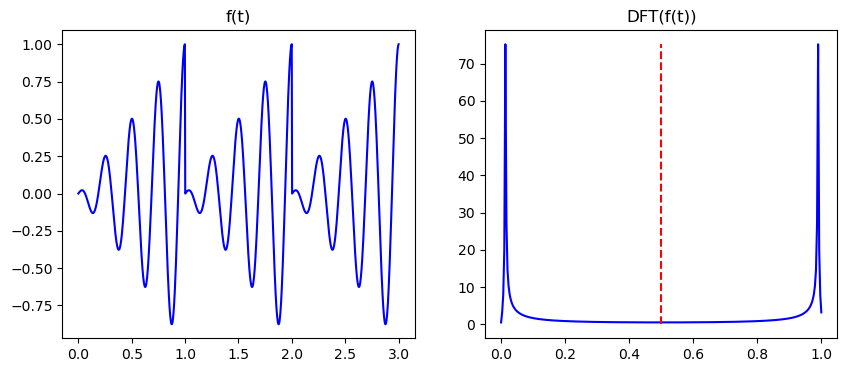

In [38]:
import numpy as np 
import matplotlib.pyplot as plt 

N_short = 300
N_long = 3*N_short
t_short = np.linspace(0, 1, N_short)
t_long = np.linspace(0, 3, N_long)

ft_short = t_short*np.cos(8*np.pi*t_short)

ft_long = np.append(ft_short, np.append(ft_short, ft_short))

f = np.linspace(0, 1, num=N_short)

def ck(y, N):
    c = np.zeros(N, dtype='complex')
    for i in range(N):
        for j in range(N):
            c[i] += y[j]*np.exp(-1j*2*np.pi*i*j/N)
    return c

c = ck(ft_short, N_short)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.plot(t_long, ft_long, 'b')
ax1.set_title("f(t)")
ax2 = fig.add_subplot(122)
ax2.plot(f, np.abs(c), 'b') 
ax2.plot([1/2, 1/2], [0, np.max(np.abs(c))], 'r', linestyle='dashed')
ax2.set_title("DFT(f(t))")

plt.show()

The output of the DFT orders the frequency axis such that:

$$
f = 0, 1/N, 2/N, \ldots, (N/2)/N, -(N/2-1)/N, -(N/2-1)/N, \ldots, -2/N, -1/N
$$

or in terms of physical values:

$$
f = 0, \Delta f, 2\Delta f, \ldots, f_{max}, -f_{max}+\Delta f, \ldots, -2\Delta f, -\Delta f
$$

When we do math with functions represented in the frequency domain, we have to keep this fact in mind. 
When we want to visually represent the spectrum, it can be helpful to rotate the frequency array, as shown below.

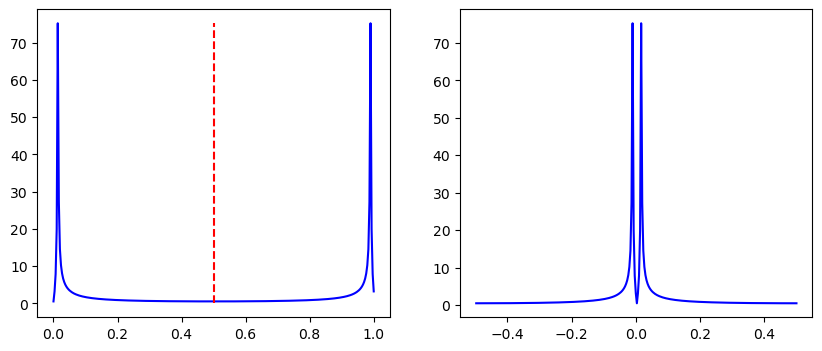

In [39]:
f_rotated = np.linspace(-149/300, 150/300, N_short)
c_rotated = np.roll(c, -150)


fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.plot(f, np.abs(c),'b')
ax1.plot([1/2, 1/2], [0, np.max(np.abs(c))], 'r', linestyle='dashed')
ax2 = fig.add_subplot(122)
ax2.plot(f_rotated, np.abs(c_rotated), 'b')

plt.show()

## Physical axis

Usually, our x-axis represents something physical. It can be space in dimension (distance), or time, or space in 2 dimensions (picture), etc.
Then, how we write the DFT and how to build the frequency axis is a little different. 

Consider the following definition:
- $L$ or $T$: The largest possible period of the signal in space or time. (For a 2D signal, there can be different periods in the different direction.) It is usually defined as the size of the array.
- $\Delta x$ or $\Delta t$: The spacing between points in space/time array.
- $f_{max}$: Maximum value of the frequency array.
- $\Delta f$: Smallest frequency increment.

We can relate these quantities to each other:

$$ 
\Delta x = \frac{L}{N}
$$

or 

$$
\Delta t = \frac{T}{N}
$$

Also,

$$
\Delta f = \frac{1}{T}
$$

In other words, the smallest frequency increment is the inverse of the longest period. 

We know that the frequency array is:

$$
f = k\Delta f = 0, \Delta f, 2\Delta f, \ldots, f_{max}, -f_{max}+\Delta f, \ldots, -2\Delta f, -\Delta f
$$

From this, we find that:

$$
f_{max} = \frac{N/2}{L} = \frac{1}{2\Delta x}
$$

or 

$$
f_{max} = \frac{N/2}{T} = \frac{1}{2\Delta t}
$$

In other words, it takes 2 points in the space/time domain to define the highest frequency. (More on that in the Nyquist section below.)

We rewrite the DFT in terms of these physical quantities. For a time function, we get:

$$
c_k = \sum_{n=0}^{N-1}y_n e^{-i2\pi k n \Delta k \Delta t}
$$

and 

$$
y_n = \frac{1}{N}\sum_{k=0}^{N-1} c_k e^{i2\pi k n \Delta f \Delta t}
$$

These relationships give us a guidebook on how to improve our signal when necessary. For example, consider a situation 
where the resolution in the frequency is insufficient. In other words, $\Delta f$ is too large. 
You might be tempted to simply increase the number of points. But, that would not work since $\Delta f$ is independent 
of $N$. What would help is increase the length of time (or space) over which data is collected or a system is modeled. 

### Example 

In the example above we can rewrite the equation as:

$$
f(t) = t\cos(8\pi t) = t\cos\left(\frac{2\pi t}{T_c}\right) = t\cos(2\pi f_c t)
$$

Where $T_c$ is the period of the cosine function and $f_c$ is its frequency. The period of the signal is $T=1$ s, we built it that way. From the equation, $T_c = 1/4$ s 
and $f_c$ = 4.

The frequency array is built with $\Delta f = 1/T = 1/1 = 1$ Hz. The max frequency is $f_{max} = 150 / T = 150$ Hz.


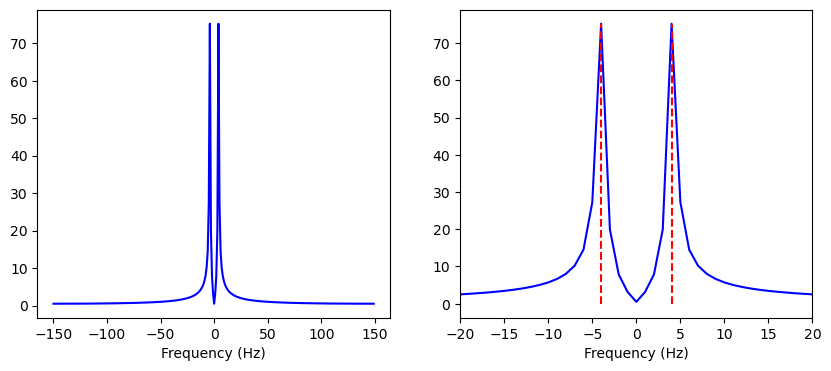

In [45]:
f_phys = np.linspace(-150, 149, num=N_short)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.plot(f_phys, np.abs(c_rotated),'b')
ax1.set_xlabel('Frequency (Hz)')
ax2 = fig.add_subplot(122)
ax2.plot(f_phys, np.abs(c_rotated), 'b')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xlim(-20,20)
ax2.plot([4, 4], [0, np.max(np.abs(c_rotated))], 'r', linestyle='dashed')
ax2.plot([-4, -4], [0, np.max(np.abs(c_rotated))], 'r', linestyle='dashed')

plt.show()



We can see that we get peaks around the period of the cosine function at 4 Hz along with additional structure 
because of the additional $t$ component to $f(t)$.

## Nyquist frequency



As mentioned above, the maximum measurable frequency in a signal is $f_{max} = 1/2\Delta t$. You need at least two time/spatial points to define the highest frequency. 

Consider the sine wave below. It might represent a physical effect you wish to model and need to figure out how many points to use to capture the physics. The sine function has 
a frequency $f_0$, corresponding to a period $T_0 = 1/f_0$. We show 3 different sampling rates:
- Undersampling: $f_s / f_0 = 1.3$ (1.3 points per period)
- The Nyquist limit: $f_s /f_0 = 2$ (2 points per period)
- Above limit sampling: $f_s / f_0 = 10$ (10 points per period)

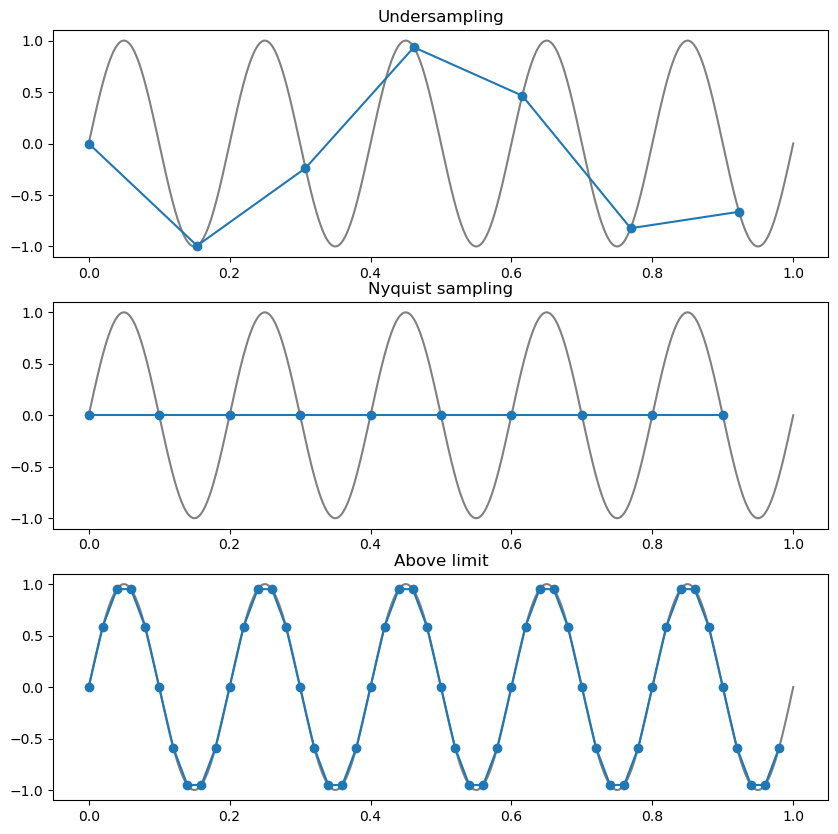

In [64]:
import numpy as np 
import matplotlib.pyplot as plt 

t = np.linspace(0, 1, 1000)
f0 = 5

def func(t, f0):
    return np.sin(2*np.pi*f0*t)

true_signal = func(t, f0)

fs = [1.3, 2.0, 10]

titles = ["Undersampling", "Nyquist sampling", "Above limit"]

fig, axes = plt.subplots(len(fs), 1, figsize=(10,10))

for i, f in enumerate(fs):
    # Create new time axis
    tt = np.arange(0, 1, 1/f/f0)
    axes[i].plot(t, true_signal, '0.5')
    axes[i].plot(tt,func(tt, f0), 'o-')
    axes[i].set_title(titles[i])

plt.show()

In the top graph, there are not enough points to properly represent the sine wave. If this is part of your model, it will not be captured. The
middle graph is the lower limit. 

We know that the Fourier transform of a sign wave at 5 Hz should return a peak at that frequency in the frequency domain. We can check that.

(*Ignore the method by which we are taking the Fourier transform for now.*)

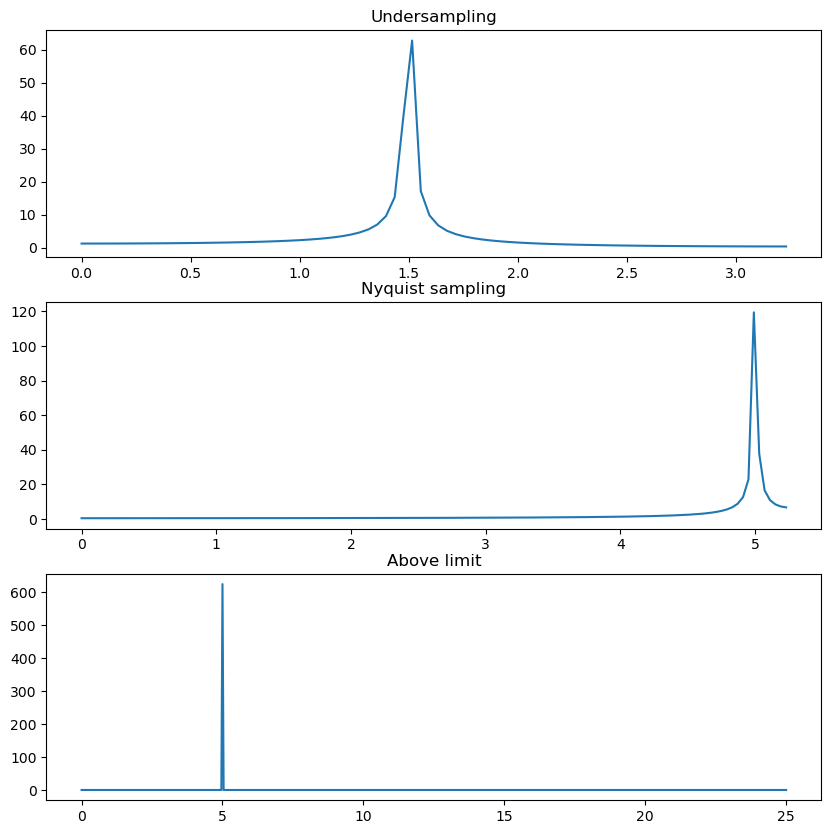

In [66]:
fs = [1.3, 2.1, 10]

fig, axes = plt.subplots(len(fs),1, figsize=(10,10))
titles = ["Undersampling", "Nyquist sampling", "Above limit"]

for i, f in enumerate(fs):
    tt = np.arange(0, 25, 1/f/f0)
    ft = func(tt, f0)
    ck = np.fft.rfft(ft)
    freq = np.fft.rfftfreq(tt.size, 1/f/f0)

    axes[i].plot(freq, np.abs(ck))
    axes[i].set_title(titles[i])

plt.show()


We can see that for sampling below the Nyquist limit, the frequency is incorrect. In fact, we can look at the reported frequency as a function of sampling rate.

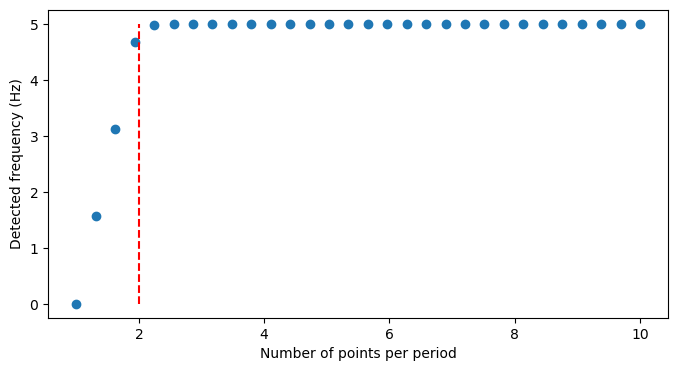

In [74]:
fs = np.linspace(1, 10, num=30)


frequency = np.zeros(30)

for i, f in enumerate(fs):
    tt = np.arange(0, 25, 1/f/f0)
    ft = func(tt, f0)
    ck = np.fft.rfft(ft)
    freq = np.fft.rfftfreq(tt.size, 1/f/f0)
    index = np.argmax(np.abs(ck))
    frequency[i] = freq[index]

fig, axes = plt.subplots(1,1, figsize=(8,4))
axes.scatter(fs, frequency)
axes.set_xlabel("Number of points per period")
axes.set_ylabel("Detected frequency (Hz)")
axes.plot([2.0, 2.0], [0.0, 5.0], 'r', linestyle='dashed')

plt.show()

The takeaway is to always make sure you have enough points in your code to properly sample the physics you are modeling.